# Recurrent Neural Network

## Part 1 - Data Preprocessing

### Importing the libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

### Importing the training set

In [2]:
dataset_train = pd.read_csv("Google_Stock_Price_Train.csv")
training_set = dataset_train.iloc[:, 1:2].values

### Feature Scaling

In [23]:
from sklearn.preprocessing import MinMaxScaler
minmax = MinMaxScaler(feature_range = (0, 1))
training_set_scaled = minmax.fit_transform(training_set)

### Creating a data structure with 60 timesteps and 1 output

In [24]:
X_train = []
y_train = []

for i in range(60, len(training_set)):
  X_train.append(training_set_scaled[i-60: i, 0])
  y_train.append(training_set_scaled[i, 0])

X_train, y_train = np.array(X_train), np.array(y_train)

### Reshaping

In [5]:
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

## Part 2 - Building and Training the RNN

### Importing the Keras libraries and packages

In [6]:
from keras.models import Sequential
from keras.layers import LSTM, Dense, Dropout

### Initialising the RNN

In [7]:
model = Sequential()

### Adding the first LSTM layer and some Dropout regularisation

In [8]:
model.add(LSTM(units = 50, input_shape = (X_train.shape[1], 1), return_sequences = True))
model.add(Dropout(0.2))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Adding a second LSTM layer and some Dropout regularisation

In [9]:
model.add(LSTM(units = 50, return_sequences = True))
model.add(Dropout(0.2))

### Adding a third LSTM layer and some Dropout regularisation

In [10]:
model.add(LSTM(units = 50, return_sequences = True))
model.add(Dropout(0.2))

### Adding a fourth LSTM layer and some Dropout regularisation

In [11]:
model.add(LSTM(units = 50))
model.add(Dropout(0.2))

### Adding the output layer

In [12]:
model.add(Dense(units = 1))

### Compiling the RNN

In [13]:
model.compile(
    optimizer = 'adam',
    loss = 'mean_squared_error'
)

### Fitting the RNN to the Training set

In [14]:
model.fit(
    X_train,
    y_train,
    batch_size = 32,
    epochs = 100
)

Epoch 1/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 12s 109ms/step - loss: 0.0396
Epoch 2/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 106ms/step - loss: 0.0063
Epoch 3/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 143ms/step - loss: 0.0060
Epoch 4/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 110ms/step - loss: 0.0050
Epoch 5/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 135ms/step - loss: 0.0049
Epoch 6/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 132ms/step - loss: 0.0047
Epoch 7/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 110ms/step - loss: 0.0043
Epoch 8/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 106ms/step - loss: 0.0046
Epoch 9/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 142ms/step - loss: 0.0040
Epoch 10/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 105ms/step - loss: 0.0043
Epoch 11/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 106ms/step - loss: 0.0041
Epoch 12/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 143ms/step - loss: 0.0039
Epoch 13/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 4s 104ms/step - loss: 0.0040
Epoch 14/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 106ms/step - loss: 0.0041
Epoch 15/100
38/38 ━━━━━━━━━━━━━━━━━━━━ 6

## Part 3 - Making the predictions and visualising the results

### Getting the real stock price of 2017

In [15]:
dataset_test = pd.read_csv("Google_Stock_Price_Test.csv")
real_stock_price = dataset_test.iloc[:, 1:2].values

### Getting the predicted stock price of 2017

In [26]:
dataset_total = pd.concat((dataset_train['Open'], dataset_test['Open']), axis = 0)
inputs = dataset_total[len(dataset_total) - len(dataset_test) - 60:].values
inputs = np.reshape(inputs, (-1, 1))
inputs = minmax.transform(inputs)

X_test = []

for i in range(60, 60 + len(dataset_test)):
  X_test.append(inputs[i - 60 : i, 0])

X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

predicted_stock_price = model.predict(X_test)
predicted_stock_price = minmax.inverse_transform(predicted_stock_price)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


### Visualising the results

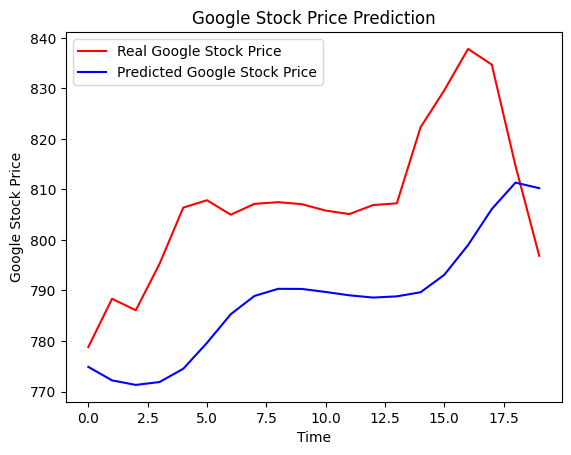

In [25]:
plt.plot(real_stock_price, color = 'red', label = "Real Google Stock Price")
plt.plot(predicted_stock_price, color = 'blue', label = "Predicted Google Stock Price")
plt.title('Google Stock Price Prediction')
plt.xlabel('Time')
plt.ylabel('Google Stock Price')
plt.legend()
plt.show()